## imports and loading data

In [32]:
# core
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.cm as cm

# utilities 
from itertools import combinations
from collections import Counter

# plot styling
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (8, 5)

In [10]:
df = pd.read_csv("../data/retail_features.csv")
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'InvoiceDay',
       'InvoiceMonth', 'InvoiceWeek', 'InvoiceHour', 'InvoiceMonthName',
       'InvoiceTotal', 'InvoiceTotalQuantity', 'InvoiceLineCount',
       'InvoiceUniqueProducts', 'InvoiceAvgPricePerUnit', 'CustomerTotalSpend',
       'CustomerNumPurchases', 'CustomerUniqueProducts', 'ProductTotalRevenue',
       'ProductTotalQuantity', 'ProductNumCustomers', 'CountryTotalRevenue',
       'CountryCustomerCount', 'CountryInvoiceCount'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Invoice                 779425 non-null  int64  
 1   StockCode               779425 non-null  object 
 2   Description             779425 non-null  object 
 3   Quantity                779425 non-null  int64  
 4   InvoiceDate             779425 non-null  object 
 5   Price                   779425 non-null  float64
 6   Customer ID             779425 non-null  int64  
 7   Country                 779425 non-null  object 
 8   TotalPrice              779425 non-null  float64
 9   InvoiceDay              779425 non-null  object 
 10  InvoiceMonth            779425 non-null  object 
 11  InvoiceWeek             779425 non-null  int64  
 12  InvoiceHour             779425 non-null  int64  
 13  InvoiceMonthName        779425 non-null  object 
 14  InvoiceTotal        

## 1. Question  
**Which customer segments generate the highest revenue and purchase frequency?**

In [12]:
# fix datetime type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [17]:
customer = (
    df.groupby("Customer ID")
      .agg(
          TotalSpend=("CustomerTotalSpend", "first"),
          NumPurchases=("CustomerNumPurchases", "first")
      )
      .reset_index()
)


In [18]:
# spend thresholds
low_spend = customer["TotalSpend"].quantile(0.50)
high_spend = customer["TotalSpend"].quantile(0.85)

def spend_segment(x):
    if x >= high_spend:
        return "High Spend"
    elif x >= low_spend:
        return "Mid Spend"
    else:
        return "Low Spend"

def freq_segment(x):
    if x == 1:
        return "One-time"
    elif x <= 5:
        return "Repeat"
    else:
        return "Loyal"

customer["SpendSegment"] = customer["TotalSpend"].apply(spend_segment)
customer["FreqSegment"] = customer["NumPurchases"].apply(freq_segment)

customer["Segment"] = customer["SpendSegment"] + " | " + customer["FreqSegment"]


In [19]:
segment_summary = (
    customer.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        AvgSpend=("TotalSpend", "mean"),
        AvgPurchases=("NumPurchases", "mean"),
        TotalRevenue=("TotalSpend", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

segment_summary


,Customers,AvgSpend,AvgPurchases,TotalRevenue
Segment,,,,
High Spend | Loyal,817,14395.573191,23.248470,1.176118e+07
Mid Spend | Loyal,929,2272.925022,8.960172,2.111547e+06
Mid Spend | Repeat,1040,1525.431531,3.623077,1.586449e+06
Low Spend | Repeat,1356,507.887375,2.676254,6.886953e+05
High Spend | Repeat,58,10865.841914,3.913793,6.302188e+05
Low Spend | One-time,1528,256.157625,1.000000,3.914089e+05
Mid Spend | One-time,88,1337.208534,1.000000,1.176744e+05
High Spend | One-time,7,7312.765714,1.000000,5.118936e+04
Low Spend | Loyal,55,662.512000,7.345455,3.643816e+04


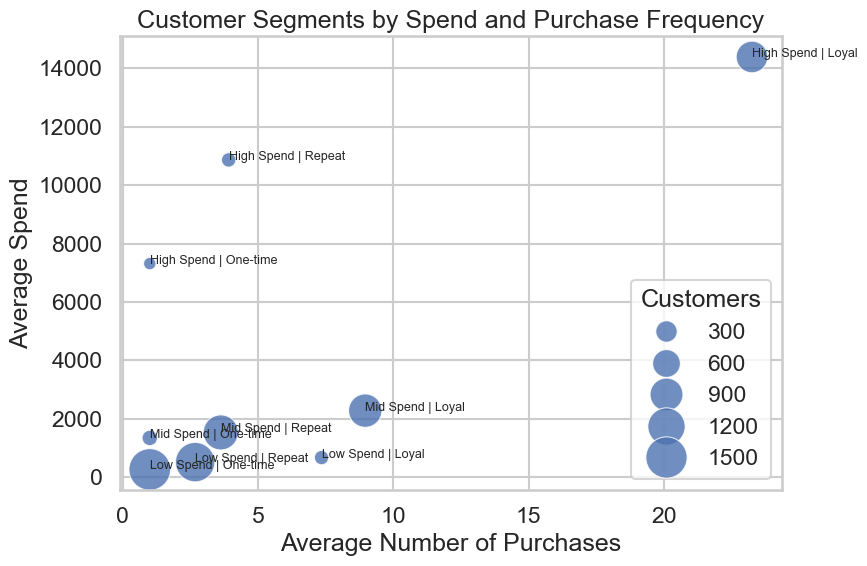

In [20]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=segment_summary,
    x="AvgPurchases",
    y="AvgSpend",
    size="Customers",
    sizes=(80, 900),
    alpha=0.8
)

for i, label in enumerate(segment_summary.index):
    plt.text(
        segment_summary["AvgPurchases"].iloc[i],
        segment_summary["AvgSpend"].iloc[i],
        label,
        fontsize=9
    )

plt.title("Customer Segments by Spend and Purchase Frequency")
plt.xlabel("Average Number of Purchases")
plt.ylabel("Average Spend")
plt.tight_layout()
plt.show()


## Answer (Insights / Analysis)

The chart segments customers using three signals: total spend, purchase frequency, and number of customers per segment.

**Key findings**

- **High Spend | Loyal** customers generate the highest revenue despite being a relatively small group.  
  Their combination of frequent purchases and high spend makes them the most valuable segment.

- **Mid Spend | Loyal** customers form a strong secondary segment.  
  Their larger population compensates for lower per-customer spend, resulting in significant total revenue.

- **Repeat buyers with low or mid spend** purchase multiple times but contribute limited revenue per customer.  
  This shows that purchase frequency alone does not imply high value.

- **One-time buyers** represent the largest customer group but contribute the least revenue overall.

**Answer to the question**

The highest revenue and purchase frequency come from **loyal customers with high spending**, while one-time and low-spend repeat customers contribute limited value.

**Conclusion**

Revenue is driven primarily by customers who combine **high spending with loyal purchasing behavior**.  
Retention efforts should focus on moving repeat and one-time buyers toward loyal, high-spend segments rather than simply increasing transaction volume.


## 2. Which products are the strongest and weakest performers based on revenue and demand volume?

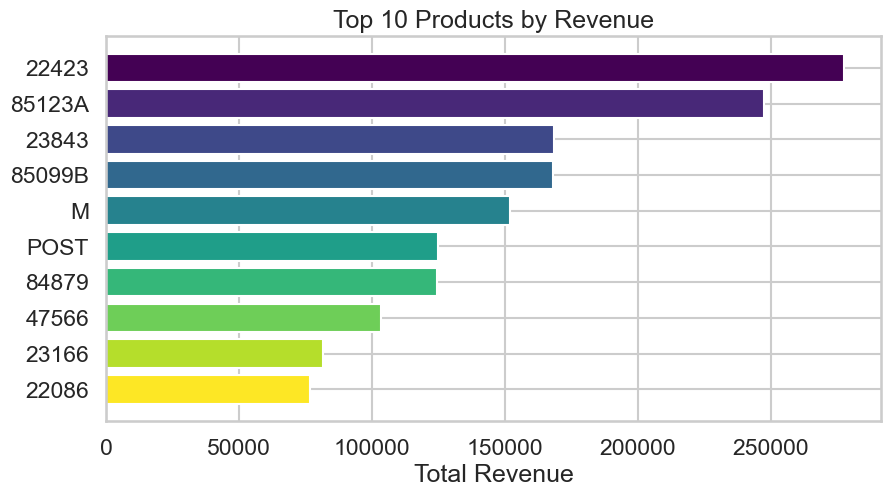

In [27]:
# top 10 products
top10 = (
    df.groupby("StockCode")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0,1,len(top10)))

plt.figure(figsize=(10,5))
plt.barh(top10["StockCode"], top10["TotalPrice"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Total Revenue")
plt.title("Top 10 Products by Revenue")
plt.show()

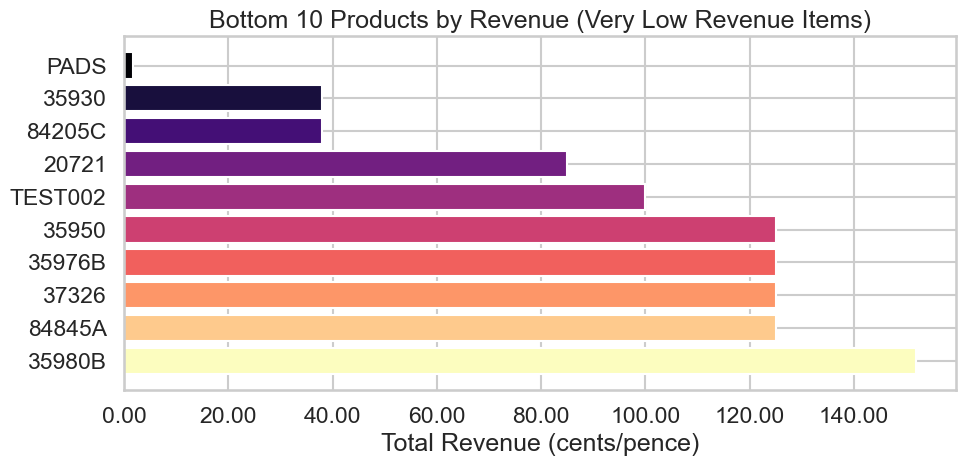

,StockCode,TotalRevenue,RevenueInCents
0,PADS,0.017,1.7
1,35930,0.380,38.0
2,84205C,0.380,38.0
3,20721,0.850,85.0
4,TEST002,1.000,100.0
5,35950,1.250,125.0
6,35976B,1.250,125.0
7,37326,1.250,125.0
8,84845A,1.250,125.0
9,35980B,1.520,152.0


In [ ]:

prod_revenue = df.groupby("StockCode")["TotalPrice"].sum().rename("TotalRevenue").reset_index()

bottom10 = prod_revenue[prod_revenue["TotalRevenue"] > 0].nsmallest(10, "TotalRevenue").reset_index(drop=True)
bottom10["RevenueInCents"] = bottom10["TotalRevenue"] * 100  # multiply to cents/pence
colors_bot = cm.magma(np.linspace(0,1,len(bottom10)))

plt.figure(figsize=(10,5))
plt.barh(bottom10["StockCode"], bottom10["RevenueInCents"], color=colors_bot)
plt.gca().invert_yaxis()
plt.xlabel("Total Revenue (cents/pence)")
plt.title("Bottom 10 Products by Revenue (Very Low Revenue Items)")
# show two decimal places (if needed)
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.2f}'))
plt.tight_layout()
plt.show()

display(bottom10)


## Answer (Insights / Analysis)

This analysis evaluates product performance using total revenue generated and total quantity sold.  
Separate views are used to clearly distinguish high-impact products from weak performers without distorting scale.

**Key findings**

- A small number of products generate a disproportionately large share of total revenue.  
  These products are the primary revenue drivers and have a significant impact on overall business performance.

- Several products generate extremely low but positive revenue.  
  Although these items are technically selling, their contribution to total revenue is negligible.

- The large gap between top and bottom products highlights strong revenue concentration at the product level.  
  Most products operate in a long tail with limited financial impact.

- High-revenue products are not always the highest-volume sellers, indicating the presence of premium or higher-priced items.

**Answer to the question**

The strongest performers are a small set of products that generate most of the revenue, while the weakest performers sell little and contribute minimally despite being present in the catalog.

**Conclusion**

Product performance cannot be judged by demand alone.  
A small set of high-revenue products drives most of the value, while many low-revenue products contribute marginally and may serve niche or traffic-driving roles rather than profitability.


## 4. Which product combinations frequently appear in the same invoice?

In [37]:
# group products per invoice
invoice_products = df.groupby("Invoice")["StockCode"].apply(list)
pair_counter = Counter()

for products in invoice_products:
    unique_items = list(set(products))  # remove duplicates in same invoice
    if len(unique_items) >= 2:
        for pair in combinations(sorted(unique_items), 2):
            pair_counter[pair] += 1


In [38]:
pairs_df = (
    pd.DataFrame(pair_counter.items(), columns=["Pair", "Count"])
    .sort_values("Count", ascending=False)
    .head(15)
)

pairs_df["ProductA"] = pairs_df["Pair"].apply(lambda x: x[0])
pairs_df["ProductB"] = pairs_df["Pair"].apply(lambda x: x[1])
pairs_df = pairs_df[["ProductA", "ProductB", "Count"]]

pairs_df


,ProductA,ProductB,Count
1438,21733,85123A,1155
559018,22386,85099B,1064
526175,20725,22384,1022
20610,20725,20727,1009
28167,82482,82494L,993
511937,20725,22383,976
34174,85099B,85099F,952
1810,21212,84991,913
16830,21931,85099B,913
512696,22382,22383,909


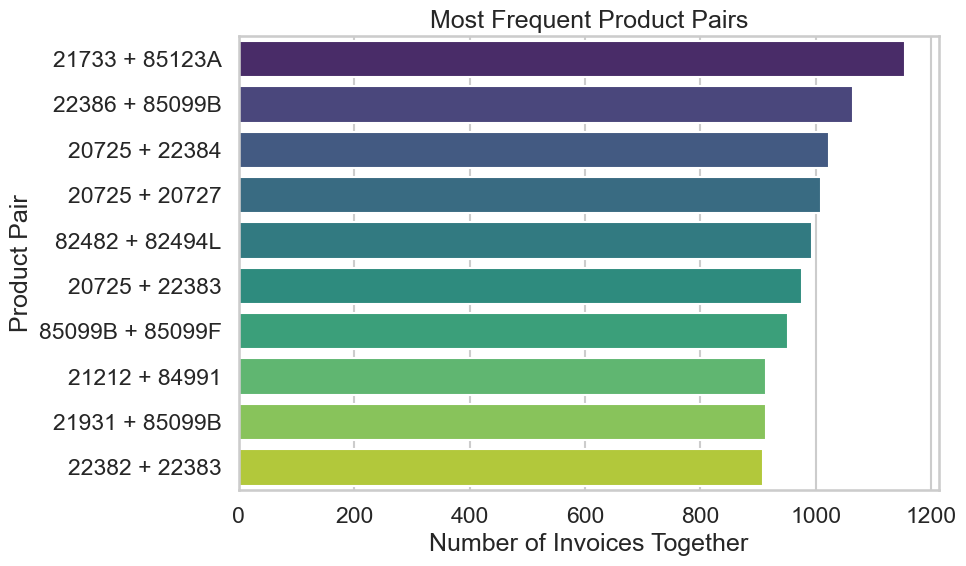

In [40]:
top_pairs = pairs_df.head(10).copy()

top_pairs["PairLabel"] = top_pairs["ProductA"] + " + " + top_pairs["ProductB"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_pairs,
    x="Count",
    y="PairLabel",
    hue="PairLabel",
    palette="viridis",
    legend=False
)

plt.xlabel("Number of Invoices Together")
plt.ylabel("Product Pair")
plt.title("Most Frequent Product Pairs")
plt.tight_layout()
plt.show()


## Answer (Insights / Analysis)

This analysis treats each invoice as a shopping basket and identifies product pairs that are frequently purchased together.

**Key findings**

- Several product pairs consistently appear together across a large number of invoices, indicating strong co-purchasing behavior.
- These combinations are not random and reflect stable customer buying patterns.
- Frequently co-purchased products are natural candidates for cross-selling, bundling, or joint promotions.

**Answer to the question**

The most frequent product combinations reveal clear and repeatable buying patterns, showing that customers often purchase specific product pairs together.

**Conclusion**

Customers often buy specific combinations of products rather than individual items in isolation.  
Identifying these frequent product pairs provides actionable insights for improving product placement, bundle design, and recommendation strategies.


## 10. Which products act as traffic drivers?

In [64]:
product_metrics = (
    df.groupby("StockCode")
      .agg(
          TotalRevenue=("TotalPrice", "sum"),
          PurchaseFrequency=("Invoice", "nunique"),
          TotalQuantity=("Quantity", "sum")
      )
      .reset_index()
)

# Average revenue generated each time the product appears in an invoice
product_metrics["RevenuePerPurchase_GBP"] = (
    product_metrics["TotalRevenue"] / product_metrics["PurchaseFrequency"]
)


In [65]:
freq_threshold = product_metrics["PurchaseFrequency"].quantile(0.75)

frequent_products = product_metrics[
    product_metrics["PurchaseFrequency"] >= freq_threshold
]


In [69]:
traffic_drivers = (
    frequent_products
    .sort_values("RevenuePerPurchase_GBP", ascending=True)
    .head(10)
)

traffic_drivers

,StockCode,TotalRevenue,PurchaseFrequency,TotalQuantity,RevenuePerPurchase_GBP
467,21034,3689.80,1857,3884,1.986968
3545,84536A,1881.58,413,4478,4.555884
1926,22753,1662.09,331,2176,5.021420
3546,84536B,1149.68,224,2861,5.132500
2753,35471D,1060.00,205,1950,5.170732
3588,84596G,1157.93,222,1967,5.215901
3370,82578,2879.35,544,5391,5.292923
1305,22093,1353.21,247,2315,5.478583
4216,85231B,1581.56,286,1868,5.529930
2088,22919,1098.85,197,1709,5.577919


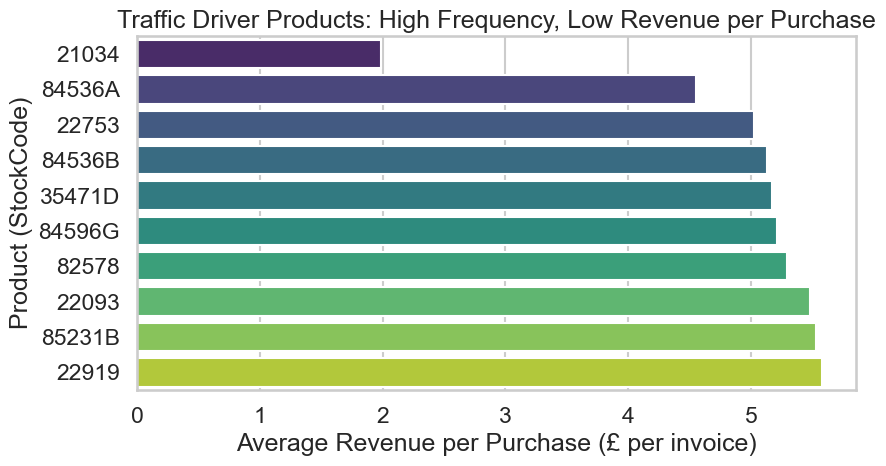

In [70]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=traffic_drivers,
    x="RevenuePerPurchase_GBP",
    y="StockCode",
    hue="StockCode",
    palette="viridis",
    legend=False
)

plt.xlabel("Average Revenue per Purchase (£ per invoice)")
plt.ylabel("Product (StockCode)")
plt.title("Traffic Driver Products: High Frequency, Low Revenue per Purchase")
plt.tight_layout()
plt.show()


## Answer (Insights / Analysis)

This analysis identifies products that are purchased very frequently but generate low average revenue per purchase.  
Such products are considered *traffic drivers* because they attract customers without directly contributing high revenue.

**Key findings**

- A distinct group of products appears in a large number of invoices while contributing only a small amount of revenue per purchase.
- These products are consistently added to customer baskets, indicating strong demand and high visibility.
- Despite their popularity, their individual contribution to revenue is low compared to other products.

**Answer to the question**

The products identified in this analysis act as **traffic drivers**: they bring customers into the store and increase engagement, but they are not primary revenue generators.  
Their value lies in supporting customer acquisition, basket expansion, and cross-selling rather than direct profitability.

**Conclusion**

Traffic driver products should be strategically used for promotions, bundles, and entry-level offers.  
Evaluating them purely on revenue would underestimate their importance in driving customer activity and overall sales.
